# Neural Network Baseline Model (v2)

Changes from v1:
- **Dropped `gsr_count`** — this feature is nearly a deterministic encoding of the label (the labels were assigned based on which elements are present, and `gsr_count` counts exactly those elements). Keeping it produced 99.9%+ accuracy, which is circular and almost guaranteed data leakage.

Remaining features: 56 (27 CLR + 27 presence + `pb_sb_over_non_ba_o_mass` + `log_pb_plus_sb`)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# Load Data, drop gsr_count

In [2]:
df = pd.read_parquet('../../data/processed/engineered_features_nn.parquet')

if 'gsr_count' in df.columns:
    df = df.drop(columns=['gsr_count'])
    print('Dropped gsr_count')

meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f'Shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Dropped gsr_count
Shape: (2294985, 61)
Features: 56
Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


In [3]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

# Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [4]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test_raw = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

In [5]:
X_train_raw = X_trainval[train_idx_rel]
X_val_raw = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]
groups_train = groups_trainval[train_idx_rel]

train_stubs = set(groups_train)
val_stubs = set(groups_trainval[val_idx_rel])
test_stubs = set(groups[test_idx])

In [6]:
assert len(train_stubs & val_stubs) == 0, 'Train-Val stub leak!'
assert len(train_stubs & test_stubs) == 0, 'Train-Test stub leak!'
assert len(val_stubs & test_stubs) == 0, 'Val-Test stub leak!'

In [8]:
print(f'Train:{len(X_train_raw):,} ({y_train.mean():.1%} GSR) | {len(train_stubs):,} stubs')
print(f'Val:{len(X_val_raw):,} ({y_val.mean():.1%} GSR) | {len(val_stubs):,} stubs')
print(f'Test:{len(X_test_raw):,} ({y_test.mean():.1%} GSR) | {len(test_stubs):,} stubs')
print(f'No stub overlap.')

Train:1,444,147 (49.7% GSR) | 2,271 stubs
Val:407,614 (37.1% GSR) | 757 stubs
Test:443,224 (47.4% GSR) | 758 stubs
No stub overlap.


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# Baseline MLP

Simple architecture: 2 hidden layers, 128 units, ReLU, dropout 0.3.
No tuning since this will be performance floor.

In [10]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model = BaselineMLP(input_dim=len(feature_cols)).to(device)

In [11]:
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 23,937


# Train (early stopping on val loss)

In [12]:
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                          torch.tensor(y_train, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                        torch.tensor(y_val, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                         torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4096, shuffle=False)

In [13]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

max_epochs = 30
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

train_losses = []
val_losses = []

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze()
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)
    
    model.eval()
    val_loss = 0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb).squeeze(), yb).item()
            n_val += 1
    val_losses.append(val_loss / n_val)
    
    print(f'Epoch {epoch+1}/{max_epochs}'
          f'Train: {train_losses[-1]:.4f}, Val: {val_losses[-1]:.4f}')
    
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_state = model.state_dict().copy()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(best_state)
print(f'Restored best model (val loss: {best_val_loss:.4f})')

Epoch 1/30Train: 0.0414, Val: 0.0053
Epoch 2/30Train: 0.0066, Val: 0.0045
Epoch 3/30Train: 0.0057, Val: 0.0041
Epoch 4/30Train: 0.0050, Val: 0.0037
Epoch 5/30Train: 0.0046, Val: 0.0032
Epoch 6/30Train: 0.0041, Val: 0.0030
Epoch 7/30Train: 0.0038, Val: 0.0027
Epoch 8/30Train: 0.0036, Val: 0.0027
Epoch 9/30Train: 0.0034, Val: 0.0023
Epoch 10/30Train: 0.0033, Val: 0.0023
Epoch 11/30Train: 0.0031, Val: 0.0024
Epoch 12/30Train: 0.0030, Val: 0.0021
Epoch 13/30Train: 0.0029, Val: 0.0022
Epoch 14/30Train: 0.0028, Val: 0.0022
Epoch 15/30Train: 0.0028, Val: 0.0019
Epoch 16/30Train: 0.0027, Val: 0.0018
Epoch 17/30Train: 0.0027, Val: 0.0022
Epoch 18/30Train: 0.0026, Val: 0.0018
Epoch 19/30Train: 0.0026, Val: 0.0018
Epoch 20/30Train: 0.0026, Val: 0.0017
Epoch 21/30Train: 0.0025, Val: 0.0017
Epoch 22/30Train: 0.0025, Val: 0.0017
Epoch 23/30Train: 0.0024, Val: 0.0017
Epoch 24/30Train: 0.0024, Val: 0.0017
Epoch 25/30Train: 0.0023, Val: 0.0018
Epoch 26/30Train: 0.0024, Val: 0.0017
Epoch 27/30Train: 0.0

# Overfitting?

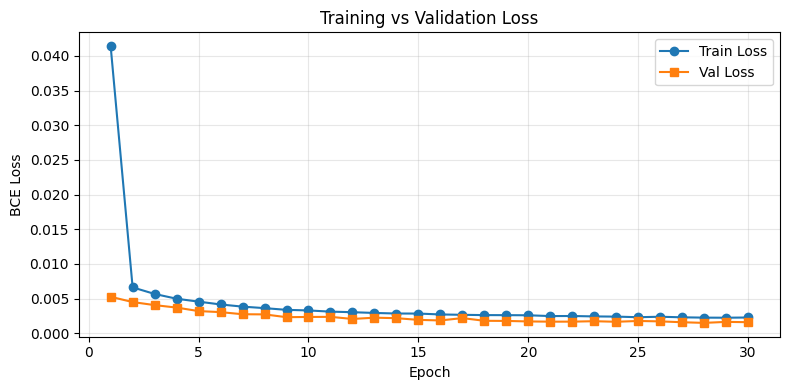

Best val loss: 0.0015
Final train loss: 0.0023
Gap (train - val): 0.0008


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best val loss: {best_val_loss:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Gap (train - val): {train_losses[len(val_losses)-1] - best_val_loss:.4f}')

# Test set eval

In [15]:
model.eval()
all_logits = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        all_logits.append(model(xb).squeeze().cpu())

logits_test = torch.cat(all_logits).numpy()
probs_test = 1 / (1 + np.exp(-logits_test))
preds_test = (probs_test >= 0.5).astype(int)

In [16]:
print('Test Set Classification Report (threshold=0.5)')
print(classification_report(y_test, preds_test, target_names=['Non_GSR', 'GSR']))

Test Set Classification Report (threshold=0.5)
              precision    recall  f1-score   support

     Non_GSR       1.00      1.00      1.00    233275
         GSR       1.00      1.00      1.00    209949

    accuracy                           1.00    443224
   macro avg       1.00      1.00      1.00    443224
weighted avg       1.00      1.00      1.00    443224



In [17]:
cm = confusion_matrix(y_test, preds_test)
print(f'Confusion Matrix:')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print(f'\nFalse Positive Rate: {cm[0,1]/(cm[0,0]+cm[0,1]):.4f}')
print(f'False Negative Rate: {cm[1,0]/(cm[1,0]+cm[1,1]):.4f}')

Confusion Matrix:
  TN=233,122  FP=153
  FN=126  TP=209,823

False Positive Rate: 0.0007
False Negative Rate: 0.0006


In [18]:
roc_auc = roc_auc_score(y_test, probs_test)
pr_auc = average_precision_score(y_test, probs_test)
print(f'ROC-AUC:{roc_auc:.4f}')
print(f'PR-AUC: {pr_auc:.4f}')

ROC-AUC: 1.0000
PR-AUC:  1.0000


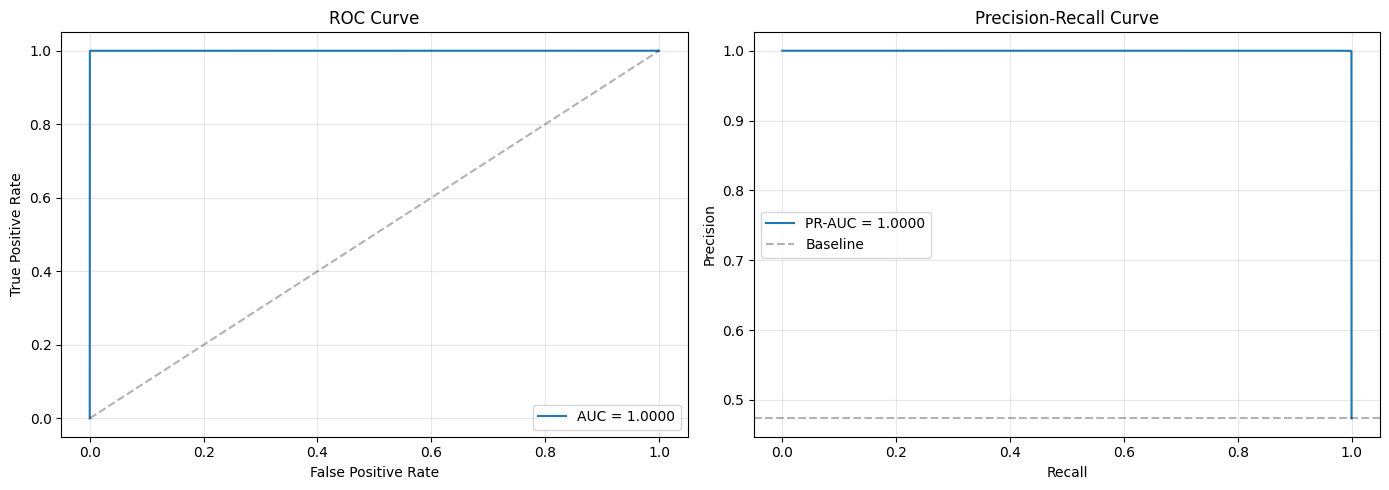

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, probs_test)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, probs_test)
axes[1].plot(rec, prec, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-Subclass Performance

In [20]:
test_classes = df['final_class'].values[test_idx]
test_labels = df['label'].values[test_idx]

results = []
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_preds = preds_test[mask]
    cls_true = y_test[mask]
    acc = (cls_preds == cls_true).mean()
    if label == 'GSR':
        rate = cls_preds.mean()
        metric_name = 'Recall'
    else:
        rate = 1 - cls_preds.mean()
        metric_name = 'Specificity'
    results.append({'Class': cls, 'Label': label, 'N': n,
                     'Accuracy': f'{acc:.4f}', metric_name: f'{rate:.4f}'})

print(pd.DataFrame(results).to_string(index=False))

 Class   Label      N Accuracy Specificity Recall
  BaAl Non_GSR  65221   0.9986      0.9986    NaN
BaCaSi Non_GSR  81503   0.9995      0.9995    NaN
  BaSb     GSR  20708   0.9954         NaN 0.9954
  CuZn Non_GSR  75472   0.9998      0.9998    NaN
GaCuSn Non_GSR    426   1.0000      1.0000    NaN
    Hg Non_GSR    678   1.0000      1.0000    NaN
  PbBa     GSR  48129   0.9994         NaN 0.9994
PbBaSb     GSR 108047   1.0000         NaN 1.0000
  PbSb     GSR  33065   1.0000         NaN 1.0000
TiZnGd Non_GSR   3434   0.9991      0.9991    NaN
  ZnTi Non_GSR   6541   1.0000      1.0000    NaN


# Cross-val (3-Fold GroupKFold)

In [21]:
def train_and_eval_cv(X_tr, y_tr, X_val, y_val, input_dim, epochs=15, lr=1e-3):
    """Train MLP, return val metrics."""
    mdl = BaselineMLP(input_dim=input_dim).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)
    crit = nn.BCEWithLogitsLoss()
    
    tr_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr, dtype=torch.float32)),
        batch_size=4096, shuffle=True)
    
    for _ in range(epochs):
        mdl.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(mdl(xb).squeeze(), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
    
    mdl.eval()
    with torch.no_grad():
        logits = mdl(torch.tensor(X_val, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_val, preds)
    
    return {
        'roc_auc': roc_auc_score(y_val, probs),
        'pr_auc': average_precision_score(y_val, probs),
        'accuracy': (preds == y_val).mean(),
        'fpr': cm[0,1] / cm[0].sum() if cm[0].sum() > 0 else 0
    }

In [22]:
gkf = GroupKFold(n_splits=3)
cv_results = []

for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_trainval, y_trainval, groups_trainval)):
    sc = StandardScaler()
    X_tr_fold = sc.fit_transform(X_trainval[tr_idx])
    X_vl_fold = sc.transform(X_trainval[vl_idx])
    
    metrics = train_and_eval_cv(X_tr_fold, y_trainval[tr_idx],
                                 X_vl_fold, y_trainval[vl_idx],
                                 input_dim=len(feature_cols))
    cv_results.append(metrics)
    print(f'Fold {fold+1}: ROC-AUC={metrics["roc_auc"]:.4f}'
          f'PR-AUC={metrics["pr_auc"]:.4f}'
          f'Acc={metrics["accuracy"]:.4f}'
          f'FPR={metrics["fpr"]:.4f}')

print(f'\nMean ROC-AUC: {np.mean([r["roc_auc"] for r in cv_results]):.4f}'
      f'± {np.std([r["roc_auc"] for r in cv_results]):.4f}')
print(f'Mean PR-AUC:  {np.mean([r["pr_auc"] for r in cv_results]):.4f}'
      f'± {np.std([r["pr_auc"] for r in cv_results]):.4f}')
print(f'Mean Acc:     {np.mean([r["accuracy"] for r in cv_results]):.4f}'
      f'± {np.std([r["accuracy"] for r in cv_results]):.4f}')
print(f'Mean FPR:     {np.mean([r["fpr"] for r in cv_results]):.4f}'
      f'± {np.std([r["fpr"] for r in cv_results]):.4f}')

Fold 1: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9991  FPR=0.0014
Fold 2: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9991  FPR=0.0016
Fold 3: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9994  FPR=0.0007

Mean ROC-AUC: 1.0000 ± 0.0000
Mean PR-AUC:  1.0000 ± 0.0000
Mean Acc:     0.9992 ± 0.0001
Mean FPR:     0.0012 ± 0.0004


# Summary

In [24]:
print('Baseline MLP v2 Summary')
print(f'Test Set')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC:{pr_auc:.4f}')
print(f'FPR:{cm[0,1]/(cm[0,0]+cm[0,1]):.4f}')
print(f'FNR: {cm[1,0]/(cm[1,0]+cm[1,1]):.4f}')
print(f'')
print(f'3-Fold CV')
print(f'ROC-AUC:{np.mean([r["roc_auc"] for r in cv_results]):.4f} +/- {np.std([r["roc_auc"] for r in cv_results]):.4f}')
print(f'PR-AUC:  {np.mean([r["pr_auc"] for r in cv_results]):.4f} +/- {np.std([r["pr_auc"] for r in cv_results]):.4f}')

Baseline MLP v2 Summary
Test Set
ROC-AUC: 1.0000
PR-AUC:1.0000
FPR:0.0007
FNR: 0.0006

3-Fold CV
ROC-AUC:1.0000 +/- 0.0000
PR-AUC:  1.0000 +/- 0.0000


## Performance still indicates issues with the original question/data set. Ambiguous particle analysis may reveal more insights.

#  Ambiguous Particle Analysis

The 506,682 ambiguous particles (Pb, Ba, Sb, Sr single-element classes) were excluded from training. Now we score them with the trained model to see how confidently it assigns them to GSR or Non-GSR. This directly addresses our research question about where automated classification breaks down and which particles need expert review.

In [25]:
df_amb = pd.read_parquet("../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [26]:
amb_meta = ["stub_id", "particle_id", "relevance_class", "merged_relevance_class", "final_class", "label"]
amb_element_cols = [c for c in df_amb.columns if c not in amb_meta]
print(f"\nElement columns: {len(amb_element_cols)}")


Element columns: 27


# Re-engineer features since we did not do this for ambiguous. 

Just copy paste functions from feature engineering notebook.

In [27]:
def multiplicative_replacement(X, delta=None):
    X = X.copy().astype(float)
    if delta is None:
        nonzero_vals = X[X > 0]
        delta = nonzero_vals.min() / 2 if len(nonzero_vals) > 0 else 1e-10
    row_sums = X.sum(axis=1, keepdims=True)
    for i in range(X.shape[0]):
        zero_mask = X[i] == 0
        n_zeros = zero_mask.sum()
        if n_zeros > 0 and row_sums[i, 0] > 0:
            X[i, zero_mask] = delta
            correction = 1 - (n_zeros * delta / row_sums[i, 0])
            X[i, ~zero_mask] *= correction
    return X

def clr_transform(X):
    log_X = np.log(X)
    geometric_mean = log_X.mean(axis=1, keepdims=True)
    return log_X - geometric_mean

In [28]:
X_amb_raw = df_amb[amb_element_cols].values
X_amb_replaced = multiplicative_replacement(X_amb_raw)
X_amb_clr = clr_transform(X_amb_replaced)
X_amb_presence = (X_amb_raw > 0).astype(np.float32)

In [29]:
total_mass = df_amb[amb_element_cols].sum(axis=1).values
denom = total_mass - df_amb["ba"].values - df_amb["o"].values
safe_denom = np.where(denom == 0, -1, denom)
pb_sb_ratio = ((df_amb["pb"].values + df_amb["sb"].values) / safe_denom).astype(np.float32)
log_pb_sb = np.log1p(df_amb["pb"].values + df_amb["sb"].values).astype(np.float32)

In [30]:
X_amb_features = np.hstack([
    X_amb_clr.astype(np.float32),
    X_amb_presence,
    pb_sb_ratio.reshape(-1, 1),
    log_pb_sb.reshape(-1, 1)
])

print(f"Ambiguous feature matrix: {X_amb_features.shape}")
print(f"Expected: ({len(df_amb)}, {len(feature_cols)})")

Ambiguous feature matrix: (506682, 56)
Expected: (506682, 56)


In [31]:
#scale with the same scaler fit on training data
X_amb_scaled = scaler.transform(X_amb_features)

In [32]:
model.eval()
with torch.no_grad():
    amb_logits = model(torch.tensor(X_amb_scaled, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
amb_probs = 1 / (1 + np.exp(-amb_logits))
amb_preds = (amb_probs >= 0.5).astype(int)

print(f"Ambiguous particles scored: {len(amb_probs):,}")

Ambiguous particles scored: 506,682


In [33]:
amb_results = []
for cls in sorted(df_amb["final_class"].unique()):
    mask = df_amb["final_class"].values == cls
    n = mask.sum()
    cls_probs = amb_probs[mask]
    cls_preds = amb_preds[mask]
    amb_results.append({
        "Class": cls,
        "N": f"{n:,}",
        "Pred GSR %": f"{cls_preds.mean():.1%}",
        "Mean P(GSR)": f"{cls_probs.mean():.4f}",
        "Median P(GSR)": f"{np.median(cls_probs):.4f}",
        "P(GSR) < 0.2": f"{(cls_probs < 0.2).mean():.1%}",
        "0.2 < P < 0.8": f"{((cls_probs >= 0.2) & (cls_probs <= 0.8)).mean():.1%}",
        "P(GSR) > 0.8": f"{(cls_probs > 0.8).mean():.1%}",
    })

print("Model predictions on ambiguous particles:")
print(pd.DataFrame(amb_results).to_string(index=False))

Model predictions on ambiguous particles:
Class       N Pred GSR % Mean P(GSR) Median P(GSR) P(GSR) < 0.2 0.2 < P < 0.8 P(GSR) > 0.8
   Ba  89,277       0.4%      0.0043        0.0000        99.5%          0.2%         0.3%
   Pb 168,334       1.8%      0.0183        0.0000        98.2%          0.0%         1.8%
   Sb 225,676       2.1%      0.0201        0.0000        97.8%          0.4%         1.8%
   Sr  23,395       0.1%      0.0011        0.0000        99.8%          0.1%         0.0%


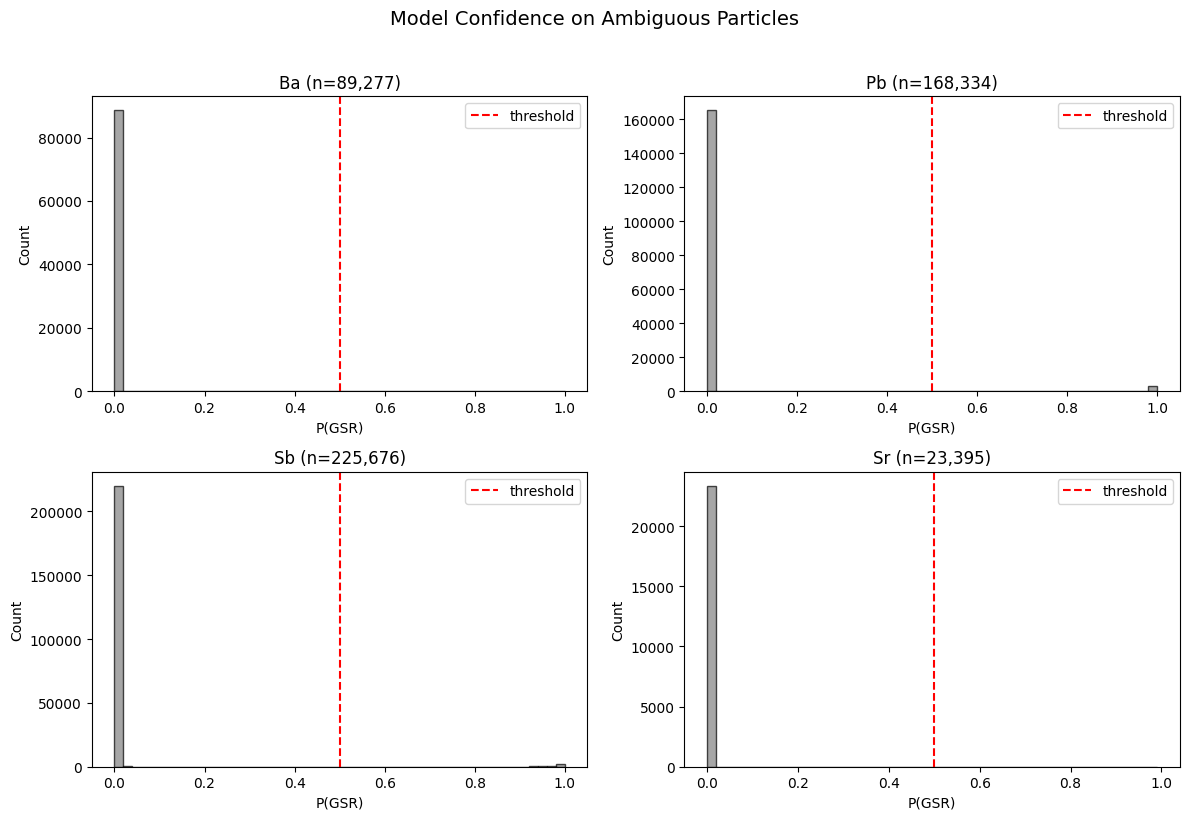

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(sorted(df_amb["final_class"].unique())):
    ax = axes[i]
    mask = df_amb["final_class"].values == cls
    cls_probs = amb_probs[mask]
    ax.hist(cls_probs, bins=50, color="gray", edgecolor="black", alpha=0.7)
    ax.axvline(x=0.5, color="red", linestyle="--", label="threshold")
    ax.set_title(f"{cls} (n={mask.sum():,})")
    ax.set_xlabel("P(GSR)")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Model Confidence on Ambiguous Particles", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()